# 02 Exploratory Data Analysis (EDA): Building Energy Efficiency Dataset

This notebook performs an intensive exploratory data analysis for the Energy Efficiency dataset. The goal is to understand how building design characteristics relate to **Heating Load** and **Cooling Load**, and to identify statistical patterns that should guide regression, semi-parametric, non-linear, and classification modeling.

The analysis is intentionally model-aware: it does not only describe the data, but also investigates distributional structure, predictor redundancy, target relationships, non-linearity, interactions, group effects, and early modeling implications.

## 1. Analytical Objectives

The EDA is structured around the following questions:

1. What is the distributional structure of each building design feature?
2. How do heating and cooling loads vary across the design space?
3. Which predictors appear most related to each energy demand outcome?
4. Are the relationships linear, monotonic, non-linear, or interaction-driven?
5. Are there strong correlations or redundancies among predictors?
6. Do categorical design factors such as orientation and glazing distribution matter?
7. What are the implications for parametric, semi-parametric, non-linear, and classification models?

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy import stats

from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 2. Load Clean Dataset

This notebook expects the cleaned dataset saved from `01_data_cleaning.ipynb` as:

```text
../data/clean/clean_df.csv
```

In [2]:
# ============================================================
# 2. LOAD CLEAN DATA
# ============================================================

DATA_PATH = Path("../data/clean/clean_df.csv")

if not DATA_PATH.exists():
    DATA_PATH = Path("data/clean/clean_df.csv")

assert DATA_PATH.exists(), f"Clean data file not found: {DATA_PATH}"

df = pd.read_csv(DATA_PATH)

print("Data path:", DATA_PATH)
print("Shape:", df.shape)
display(df.head())
display(df.tail())

Data path: data\clean\clean_df.csv
Shape: (768, 11)


,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_distribution,heating_load,cooling_load,any_outlier_flag
0,0.9800,514.5000,294.0000,110.2500,7.0000,2,0.0000,0,15.5500,21.3300,False
1,0.9800,514.5000,294.0000,110.2500,7.0000,3,0.0000,0,15.5500,21.3300,False
2,0.9800,514.5000,294.0000,110.2500,7.0000,4,0.0000,0,15.5500,21.3300,False
3,0.9800,514.5000,294.0000,110.2500,7.0000,5,0.0000,0,15.5500,21.3300,False
4,0.9000,563.5000,318.5000,122.5000,7.0000,2,0.0000,0,20.8400,28.2800,False


,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_distribution,heating_load,cooling_load,any_outlier_flag
763,0.6400,784.0000,343.0000,220.5000,3.5000,5,0.4000,5,17.8800,21.4000,False
764,0.6200,808.5000,367.5000,220.5000,3.5000,2,0.4000,5,16.5400,16.8800,False
765,0.6200,808.5000,367.5000,220.5000,3.5000,3,0.4000,5,16.4400,17.1100,False
766,0.6200,808.5000,367.5000,220.5000,3.5000,4,0.4000,5,16.4800,16.6100,False
767,0.6200,808.5000,367.5000,220.5000,3.5000,5,0.4000,5,16.6400,16.0300,False


In [3]:
# ============================================================
# 3. VARIABLE GROUPS
# ============================================================

feature_cols = [
    "relative_compactness",
    "surface_area",
    "wall_area",
    "roof_area",
    "overall_height",
    "orientation",
    "glazing_area",
    "glazing_area_distribution",
]

target_cols = ["heating_load", "cooling_load"]

continuous_features = [
    "relative_compactness",
    "surface_area",
    "wall_area",
    "roof_area",
    "overall_height",
    "glazing_area",
]

categorical_features = [
    "orientation",
    "glazing_area_distribution",
]

# Keep numerical versions for correlation and ML-style EDA.
for col in categorical_features:
    df[col] = df[col].astype("category")

print("Continuous features:", continuous_features)
print("Categorical features:", categorical_features)
print("Targets:", target_cols)
print("\nData types:")
print(df.dtypes)

Continuous features: ['relative_compactness', 'surface_area', 'wall_area', 'roof_area', 'overall_height', 'glazing_area']
Categorical features: ['orientation', 'glazing_area_distribution']
Targets: ['heating_load', 'cooling_load']

Data types:
relative_compactness          float64
surface_area                  float64
wall_area                     float64
roof_area                     float64
overall_height                float64
orientation                  category
glazing_area                  float64
glazing_area_distribution    category
heating_load                  float64
cooling_load                  float64
any_outlier_flag                 bool
dtype: object


## Structural Overview

This section confirms the working dataset dimensions, variable types, missingness, and uniqueness. Since the cleaning notebook already established that the dataset is complete, this EDA stage focuses more on structure and modeling implications than on cleaning.

In [4]:
# ============================================================
# STRUCTURAL SUMMARY
# ============================================================

structural_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null_count": df.notna().sum(),
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100,
    "unique_count": df.nunique(),
})

display(structural_summary)

,dtype,non_null_count,missing_count,missing_percent,unique_count
relative_compactness,float64,768,0,0.0000,12
surface_area,float64,768,0,0.0000,12
wall_area,float64,768,0,0.0000,7
roof_area,float64,768,0,0.0000,4
overall_height,float64,768,0,0.0000,2
orientation,category,768,0,0.0000,4
glazing_area,float64,768,0,0.0000,4
glazing_area_distribution,category,768,0,0.0000,6
heating_load,float64,768,0,0.0000,587
cooling_load,float64,768,0,0.0000,636


> **Note:** Although `orientation` and `glazing_area_distribution` are stored as numeric codes in the raw dataset, they represent categories rather than continuous measurements. These variables were therefore converted to categorical data types to preserve their semantic meaning and ensure appropriate exploratory analysis and modeling.

In [7]:
# ============================================================
# DESCRIPTIVE STATISTICS
# ============================================================

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
relative_compactness,768.0000,NaN,NaN,NaN,0.7642,0.1058,0.6200,0.6825,0.7500,0.8300,0.9800
surface_area,768.0000,NaN,NaN,NaN,671.7083,88.0861,514.5000,606.3750,673.7500,741.1250,808.5000
wall_area,768.0000,NaN,NaN,NaN,318.5000,43.6265,245.0000,294.0000,318.5000,343.0000,416.5000
roof_area,768.0000,NaN,NaN,NaN,176.6042,45.1660,110.2500,140.8750,183.7500,220.5000,220.5000
overall_height,768.0000,NaN,NaN,NaN,5.2500,1.7511,3.5000,3.5000,5.2500,7.0000,7.0000
orientation,768.0000,4.0000,2.0000,192.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
glazing_area,768.0000,NaN,NaN,NaN,0.2344,0.1332,0.0000,0.1000,0.2500,0.4000,0.4000
glazing_area_distribution,768.0000,6.0000,1.0000,144.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
heating_load,768.0000,NaN,NaN,NaN,22.3072,10.0902,6.0100,12.9925,18.9500,31.6675,43.1000
cooling_load,768.0000,NaN,NaN,NaN,24.5878,9.5133,10.9000,15.6200,22.0800,33.1325,48.0300


In [10]:
# ============================================================
# EXTENDED NUMERIC SUMMARY
# ============================================================

numeric_df = df.copy()
for col in categorical_features:
    numeric_df[col] = numeric_df[col].astype(int)

extended_summary = pd.DataFrame(index=continuous_features + target_cols)
extended_summary["mean"] = df[continuous_features + target_cols].mean()
extended_summary["median"] = df[continuous_features + target_cols].median()
extended_summary["std"] = df[continuous_features + target_cols].std()
extended_summary["min"] = df[continuous_features + target_cols].min()
extended_summary["q1"] = df[continuous_features + target_cols].quantile(0.25)
extended_summary["q3"] = df[continuous_features + target_cols].quantile(0.75)
extended_summary["max"] = df[continuous_features + target_cols].max()
extended_summary["iqr"] = extended_summary["q3"] - extended_summary["q1"]
extended_summary["skewness"] = df[continuous_features + target_cols].skew()
extended_summary["kurtosis"] = df[continuous_features + target_cols].kurtosis()

display(extended_summary)

,mean,median,std,min,q1,q3,max,iqr,skewness,kurtosis
relative_compactness,0.7642,0.7500,0.1058,0.6200,0.6825,0.8300,0.9800,0.1475,0.4955,-0.7066
surface_area,671.7083,673.7500,88.0861,514.5000,606.3750,741.1250,808.5000,134.7500,-0.1251,-1.0595
wall_area,318.5000,318.5000,43.6265,245.0000,294.0000,343.0000,416.5000,49.0000,0.5334,0.1166
roof_area,176.6042,183.7500,45.1660,110.2500,140.8750,220.5000,220.5000,79.6250,-0.1628,-1.7769
overall_height,5.2500,5.2500,1.7511,3.5000,3.5000,7.0000,7.0000,3.5000,0.0000,-2.0052
glazing_area,0.2344,0.2500,0.1332,0.0000,0.1000,0.4000,0.4000,0.3000,-0.0603,-1.3276
heating_load,22.3072,18.9500,10.0902,6.0100,12.9925,31.6675,43.1000,18.6750,0.3604,-1.2456
cooling_load,24.5878,22.0800,9.5133,10.9000,15.6200,33.1325,48.0300,17.5125,0.3960,-1.1472


## Univariate Distribution Analysis

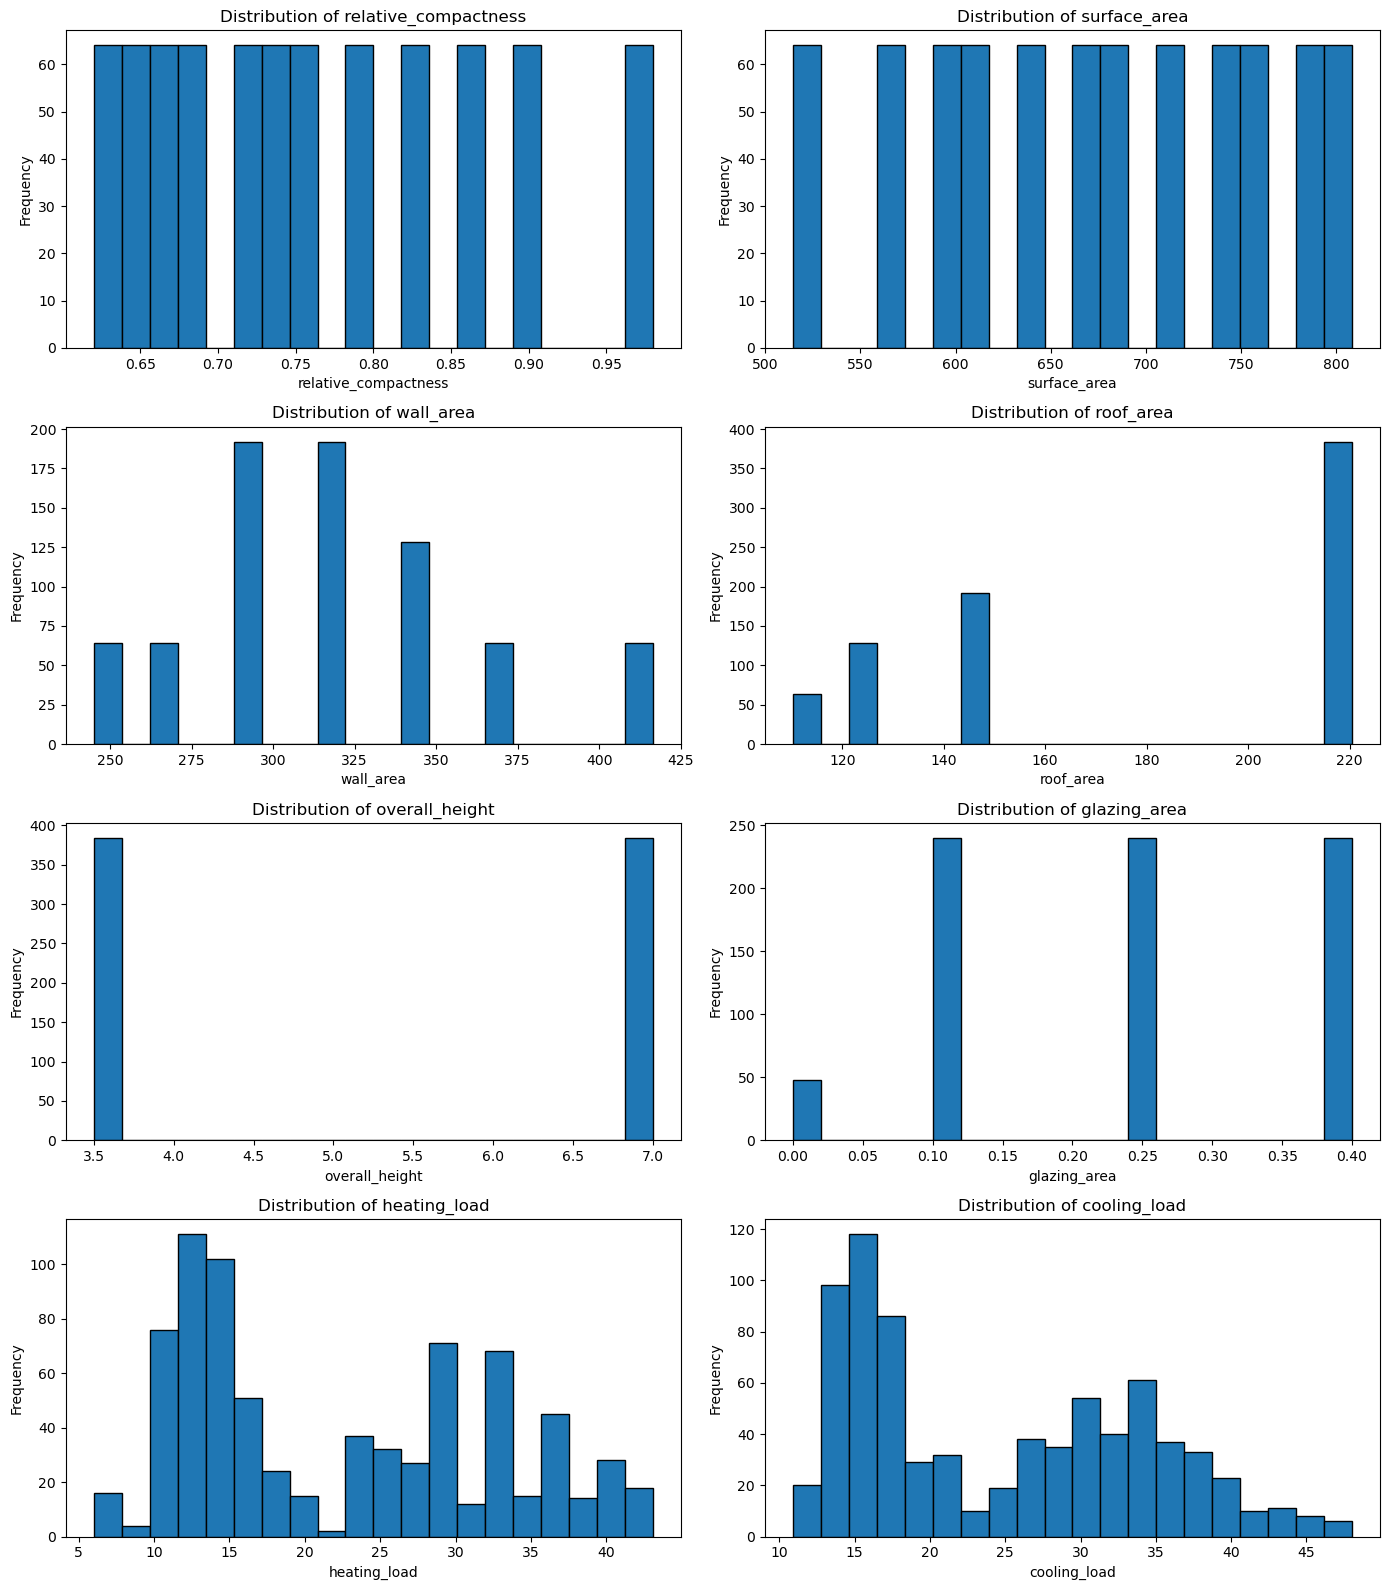

In [11]:
# ============================================================
#  HISTOGRAMS: FEATURES AND TARGETS, TWO PER ROW
# ============================================================

plot_cols = continuous_features + target_cols
n_cols = 2
n_rows = int(np.ceil(len(plot_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    axes[i].hist(df[col].dropna(), bins=20, edgecolor="black")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

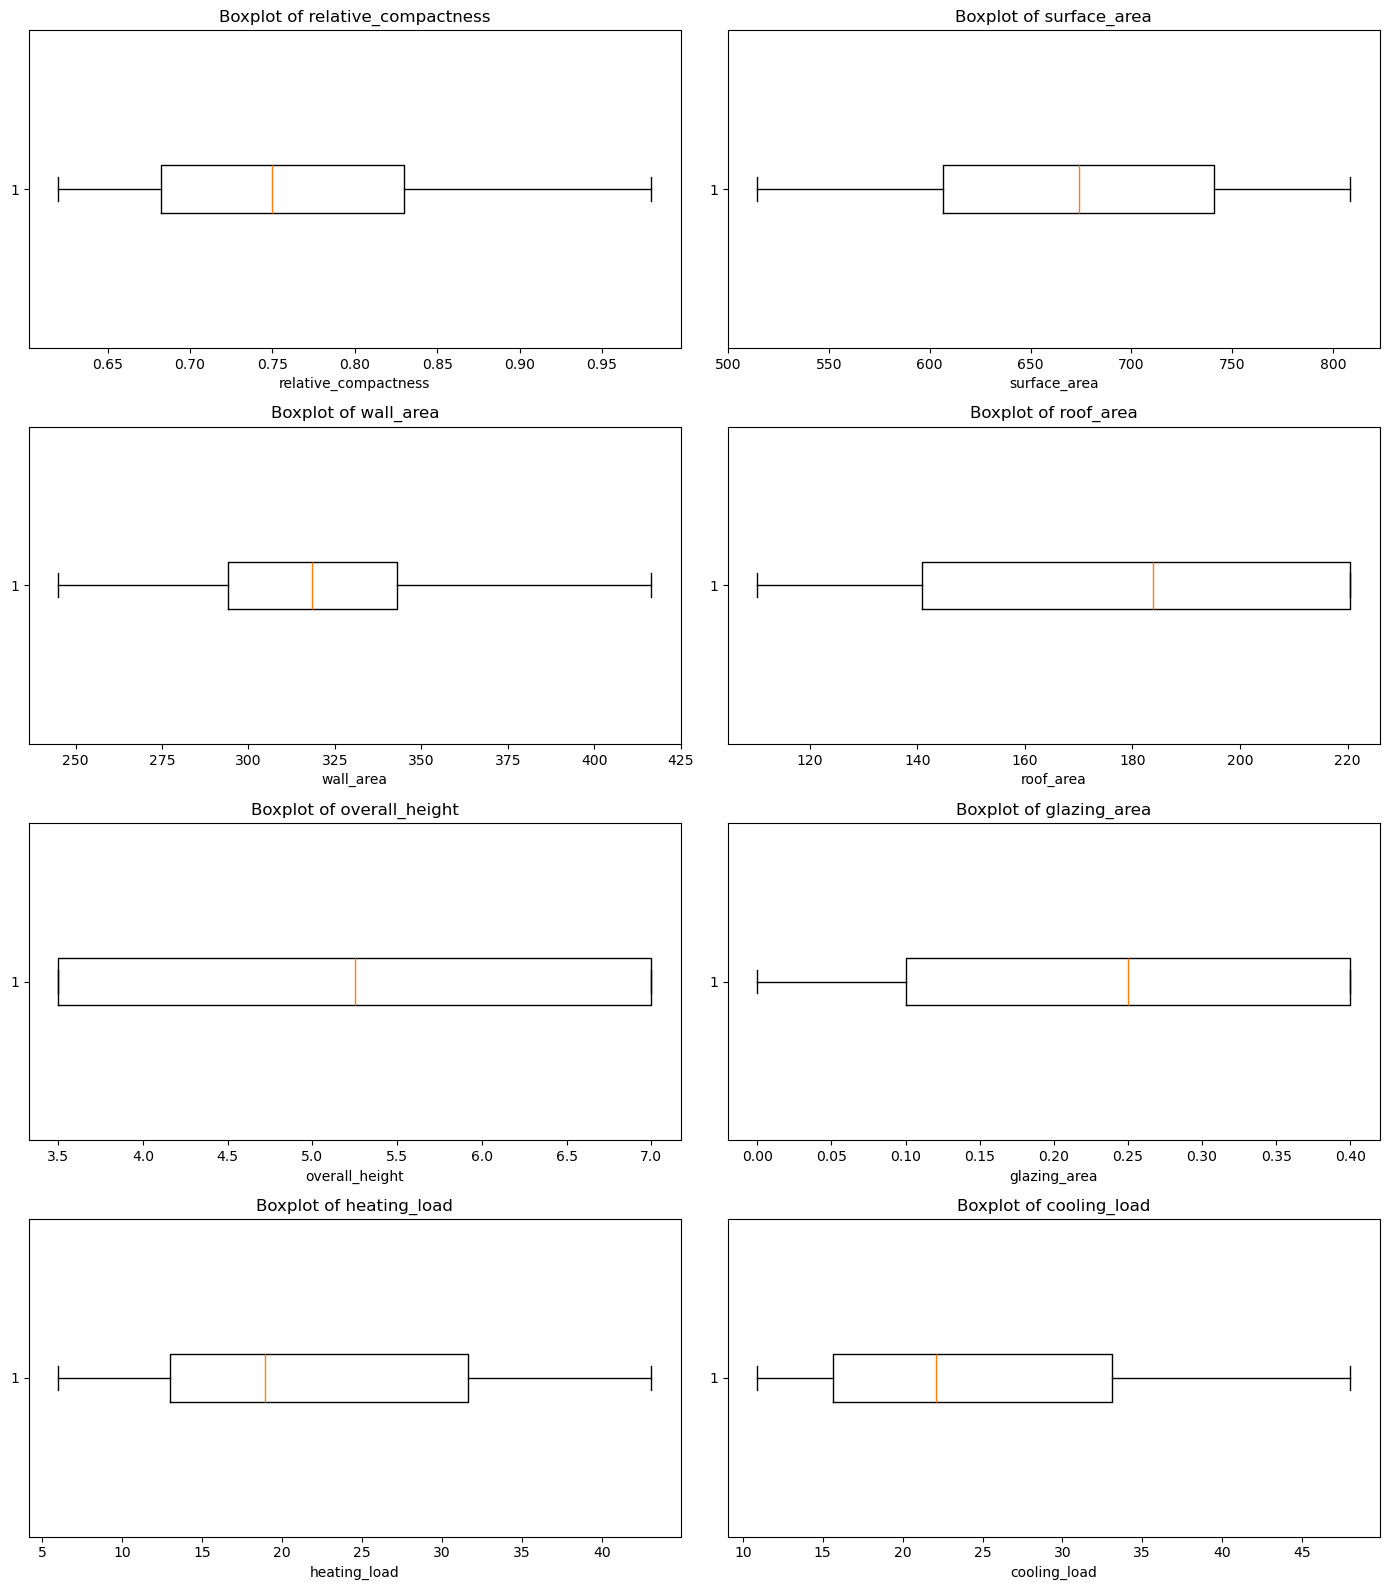

In [12]:
# ============================================================
# BOXPLOTS: CONTINUOUS FEATURES AND TARGETS
# ============================================================

plot_cols = continuous_features + target_cols
n_cols = 2
n_rows = int(np.ceil(len(plot_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    axes[i].boxplot(df[col].dropna(), vert=False)
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_xlabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Frequency table for orientation


,count,percent
orientation,,
2,192,25.0000
3,192,25.0000
4,192,25.0000
5,192,25.0000


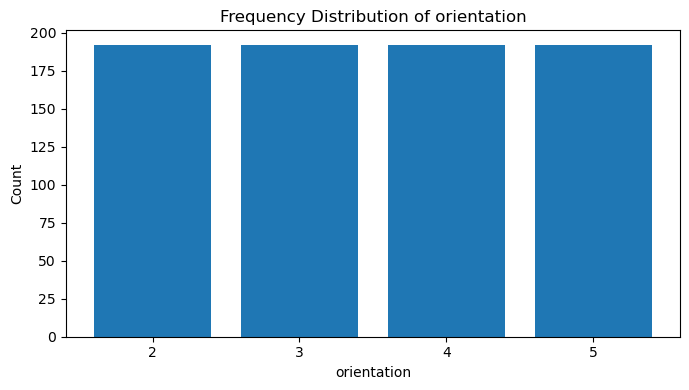


Frequency table for glazing_area_distribution


,count,percent
glazing_area_distribution,,
0,48,6.2500
1,144,18.7500
2,144,18.7500
3,144,18.7500
4,144,18.7500
5,144,18.7500


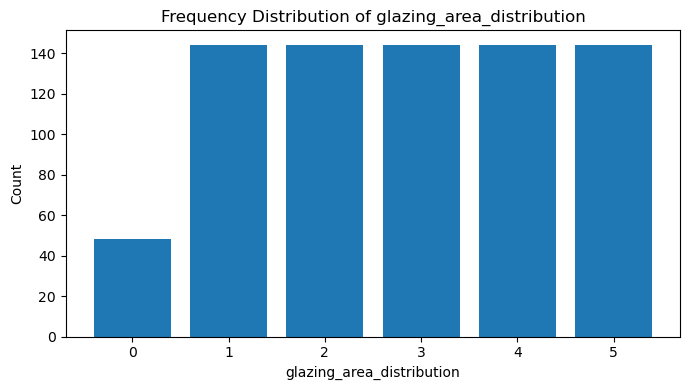

In [13]:
# ============================================================
# CATEGORICAL FEATURE FREQUENCIES
# ============================================================

for col in categorical_features:
    freq = df[col].value_counts().sort_index().rename("count").to_frame()
    freq["percent"] = freq["count"] / len(df) * 100
    print(f"\nFrequency table for {col}")
    display(freq)

    plt.figure(figsize=(7, 4))
    plt.bar(freq.index.astype(str), freq["count"])
    plt.title(f"Frequency Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

## Target Variable Analysis

Heating Load and Cooling Load are analyzed separately and jointly. Since both are energy demand outcomes, their association is important. A strong relationship between them may justify multi-output modeling or comparative model diagnostics.


Target: heating_load
Skewness: 0.3604456768846134
Kurtosis: -1.245568657654432
Shapiro-Wilk statistic: 0.9121
Shapiro-Wilk p-value: 0.000000


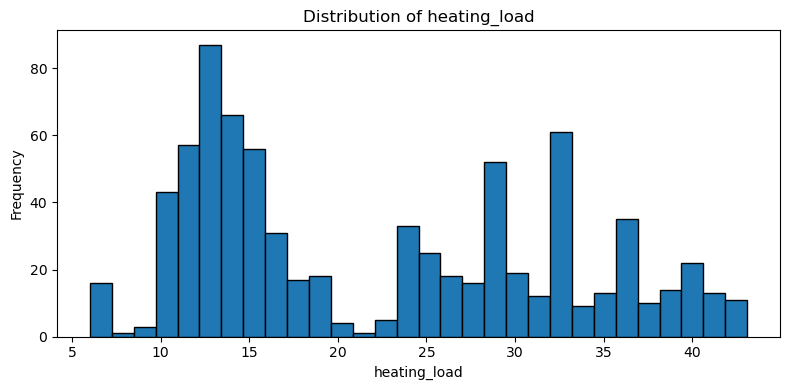

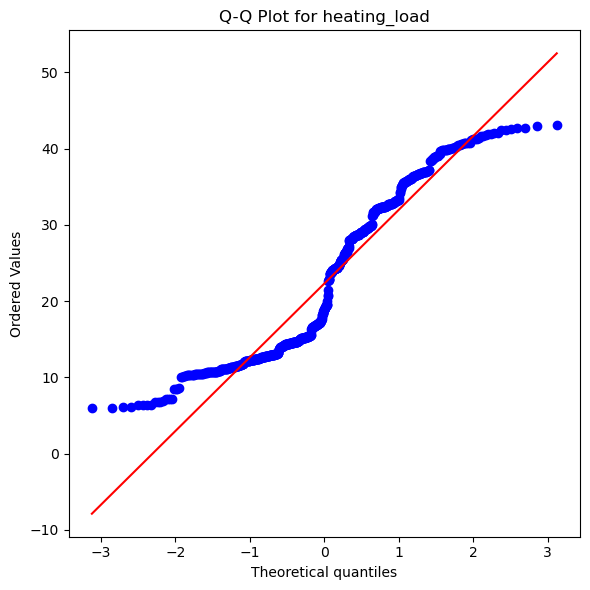


Target: cooling_load
Skewness: 0.39599246696276713
Kurtosis: -1.147190344735039
Shapiro-Wilk statistic: 0.9090
Shapiro-Wilk p-value: 0.000000


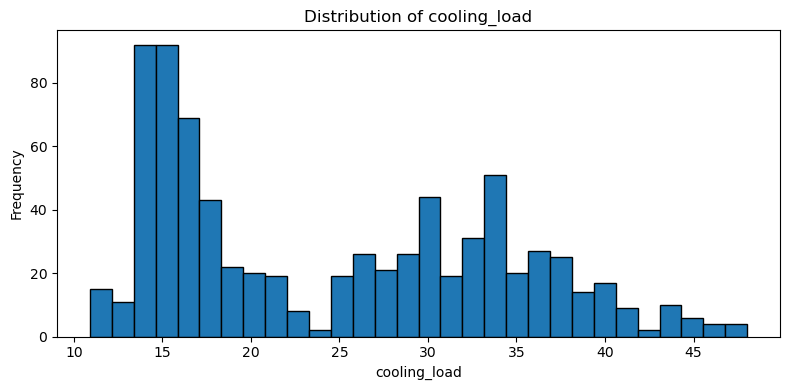

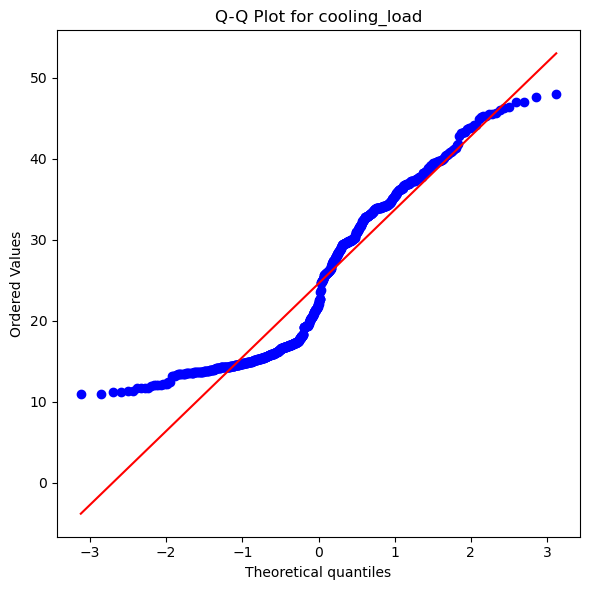

In [14]:
# ============================================================
# TARGET DISTRIBUTIONS AND NORMALITY CHECKS
# ============================================================

for target in target_cols:
    print(f"\nTarget: {target}")
    print("Skewness:", df[target].skew())
    print("Kurtosis:", df[target].kurtosis())

    stat, p_value = stats.shapiro(df[target])
    print(f"Shapiro-Wilk statistic: {stat:.4f}")
    print(f"Shapiro-Wilk p-value: {p_value:.6f}")

    plt.figure(figsize=(8, 4))
    plt.hist(df[target], bins=30, edgecolor="black")
    plt.title(f"Distribution of {target}")
    plt.xlabel(target)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 6))
    stats.probplot(df[target], dist="norm", plot=plt)
    plt.title(f"Q-Q Plot for {target}")
    plt.tight_layout()
    plt.show()

Pearson correlation:  0.9759 (p-value = 0)
Spearman correlation: 0.9727 (p-value = 0)


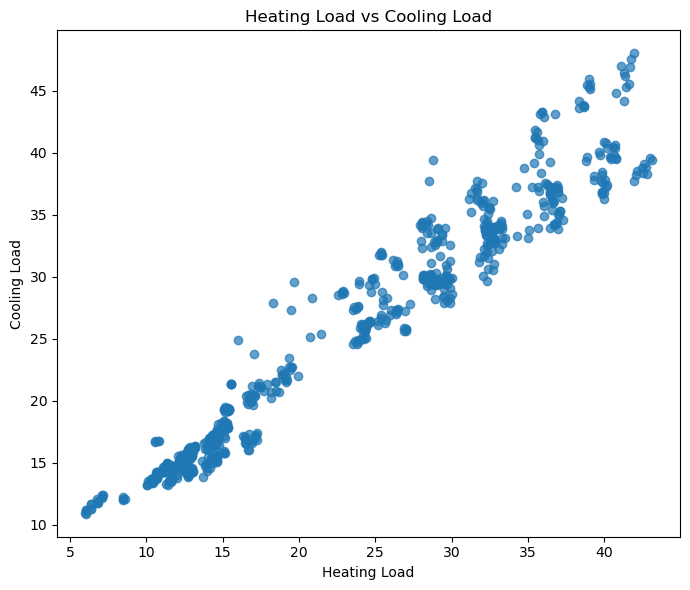

In [15]:
# ============================================================
# JOINT RELATIONSHIP BETWEEN HEATING AND COOLING LOAD
# ============================================================

r_pearson, p_pearson = stats.pearsonr(df["heating_load"], df["cooling_load"])
r_spearman, p_spearman = stats.spearmanr(df["heating_load"], df["cooling_load"])

print(f"Pearson correlation:  {r_pearson:.4f} (p-value = {p_pearson:.6g})")
print(f"Spearman correlation: {r_spearman:.4f} (p-value = {p_spearman:.6g})")

plt.figure(figsize=(7, 6))
plt.scatter(df["heating_load"], df["cooling_load"], alpha=0.7)
plt.title("Heating Load vs Cooling Load")
plt.xlabel("Heating Load")
plt.ylabel("Cooling Load")
plt.tight_layout()
plt.show()

## Correlation and Redundancy Analysis

Correlation analysis is useful here because several geometric predictors are mathematically related. This is especially important for linear regression because high predictor redundancy can make coefficient estimates unstable even when predictive accuracy is high.

,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_distribution,heating_load,cooling_load
relative_compactness,1.0000,-0.9919,-0.2038,-0.8688,0.8277,0.0000,-0.0000,-0.0000,0.6223,0.6343
surface_area,-0.9919,1.0000,0.1955,0.8807,-0.8581,-0.0000,0.0000,0.0000,-0.6581,-0.6730
wall_area,-0.2038,0.1955,1.0000,-0.2923,0.2810,-0.0000,-0.0000,0.0000,0.4557,0.4271
roof_area,-0.8688,0.8807,-0.2923,1.0000,-0.9725,-0.0000,-0.0000,-0.0000,-0.8618,-0.8625
overall_height,0.8277,-0.8581,0.2810,-0.9725,1.0000,0.0000,0.0000,-0.0000,0.8894,0.8958
orientation,0.0000,-0.0000,-0.0000,-0.0000,0.0000,1.0000,-0.0000,-0.0000,-0.0026,0.0143
glazing_area,-0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,1.0000,0.2130,0.2698,0.2075
glazing_area_distribution,-0.0000,0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.2130,1.0000,0.0874,0.0505
heating_load,0.6223,-0.6581,0.4557,-0.8618,0.8894,-0.0026,0.2698,0.0874,1.0000,0.9759
cooling_load,0.6343,-0.6730,0.4271,-0.8625,0.8958,0.0143,0.2075,0.0505,0.9759,1.0000


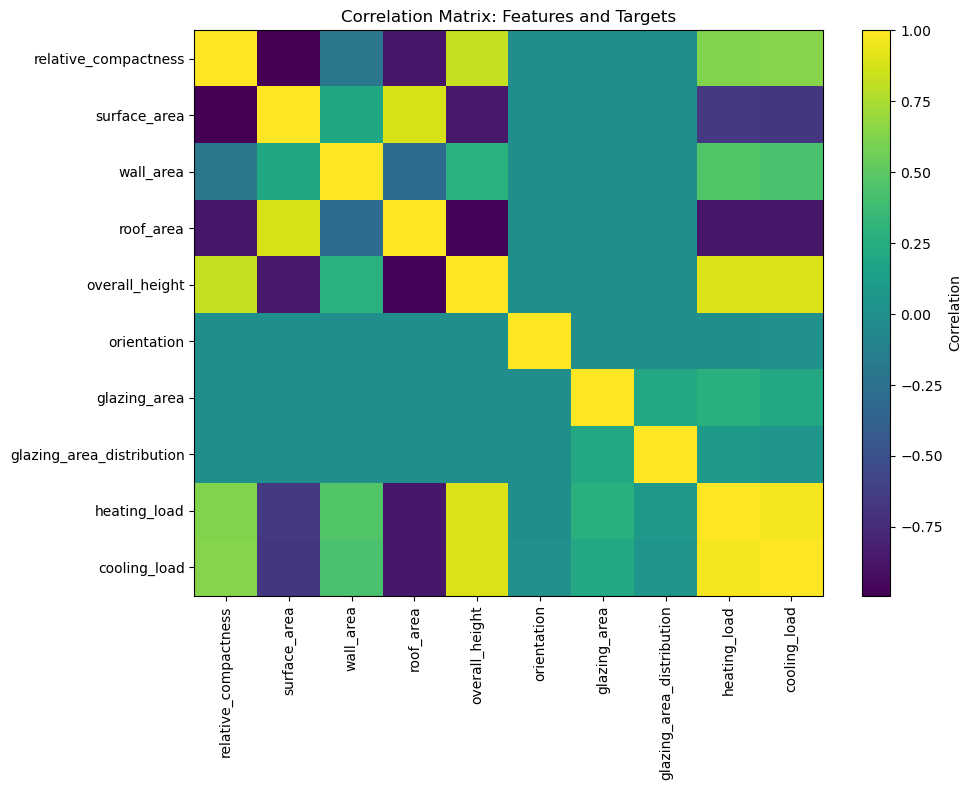

In [16]:
# ============================================================
# CORRELATION MATRIX
# ============================================================

corr_df = numeric_df[feature_cols + target_cols].corr()
display(corr_df)

plt.figure(figsize=(10, 8))
plt.imshow(corr_df, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=90)
plt.yticks(range(len(corr_df.index)), corr_df.index)
plt.title("Correlation Matrix: Features and Targets")
plt.tight_layout()
plt.show()

In [17]:
# ============================================================
#  HIGH CORRELATION PAIRS AMONG FEATURES
# ============================================================

feature_corr = numeric_df[feature_cols].corr()

high_corr_pairs = []
for i, col1 in enumerate(feature_corr.columns):
    for col2 in feature_corr.columns[i + 1:]:
        r = feature_corr.loc[col1, col2]
        if abs(r) >= 0.90:
            high_corr_pairs.append({
                "feature_1": col1,
                "feature_2": col2,
                "correlation": r,
                "abs_correlation": abs(r),
            })

high_corr_pairs = pd.DataFrame(high_corr_pairs)

if not high_corr_pairs.empty:
    high_corr_pairs = high_corr_pairs.sort_values("abs_correlation", ascending=False)

display(high_corr_pairs)

,feature_1,feature_2,correlation,abs_correlation
0,relative_compactness,surface_area,-0.9919,0.9919
1,roof_area,overall_height,-0.9725,0.9725


In [18]:
# ============================================================
# VARIANCE INFLATION FACTOR (VIF)
# ============================================================

X_vif = numeric_df[feature_cols].astype(float).copy()
X_vif = sm.add_constant(X_vif)

vif_table = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

vif_table = vif_table[vif_table["variable"] != "const"].sort_values("VIF", ascending=False)
display(vif_table)

,variable,VIF
2,surface_area,inf
3,wall_area,inf
4,roof_area,inf
1,relative_compactness,105.5241
5,overall_height,31.2055
7,glazing_area,1.0475
8,glazing_area_distribution,1.0475
6,orientation,1.0000


### VIF Interpretation Guide

- VIF < 5: usually acceptable
- VIF 5–10: moderate multicollinearity concern
- VIF > 10: serious multicollinearity concern
- Extremely large or infinite VIF: near-exact linear dependency among predictors

## Predictor-Target Relationship Analysis

This section examines how each feature relates to each target. The purpose is not to fit final models yet, but to detect whether linear regression is likely to be sufficient or whether non-linear and interaction-based models will be needed.

In [19]:
# ============================================================
# CORRELATION OF FEATURES WITH EACH TARGET
# ============================================================

target_corr = corr_df.loc[feature_cols, target_cols].copy()
target_corr["max_abs_target_corr"] = target_corr.abs().max(axis=1)
target_corr = target_corr.sort_values("max_abs_target_corr", ascending=False)

display(target_corr)

,heating_load,cooling_load,max_abs_target_corr
overall_height,0.8894,0.8958,0.8958
roof_area,-0.8618,-0.8625,0.8625
surface_area,-0.6581,-0.6730,0.6730
relative_compactness,0.6223,0.6343,0.6343
wall_area,0.4557,0.4271,0.4557
glazing_area,0.2698,0.2075,0.2698
glazing_area_distribution,0.0874,0.0505,0.0874
orientation,-0.0026,0.0143,0.0143


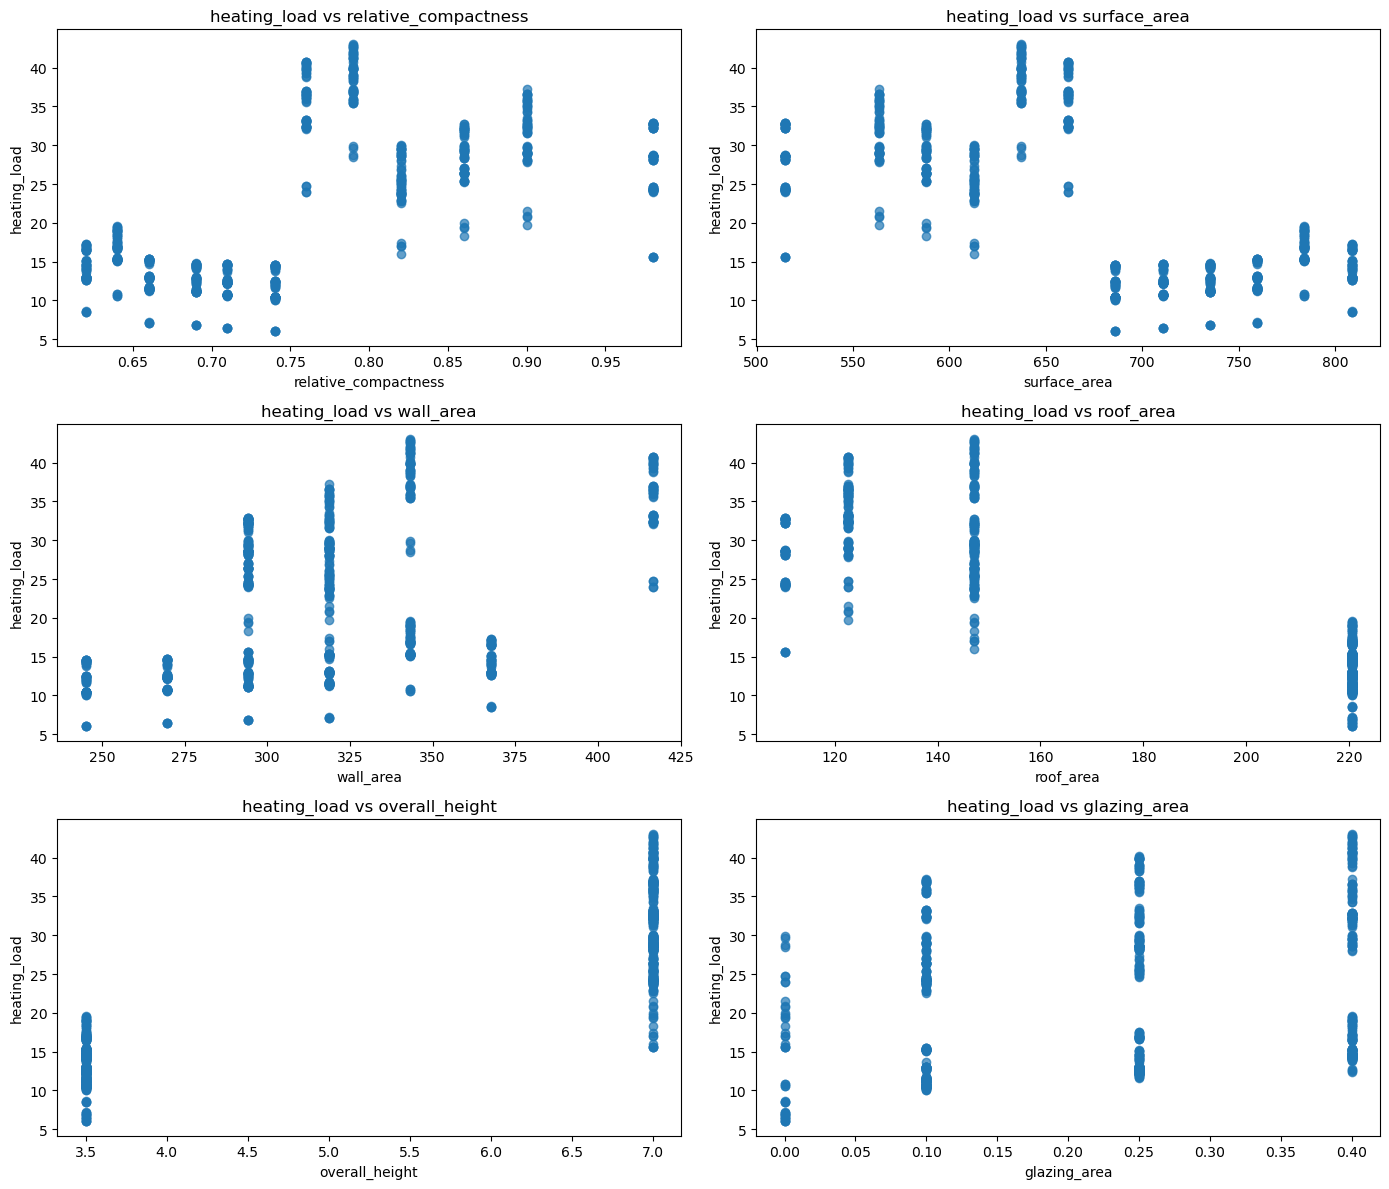

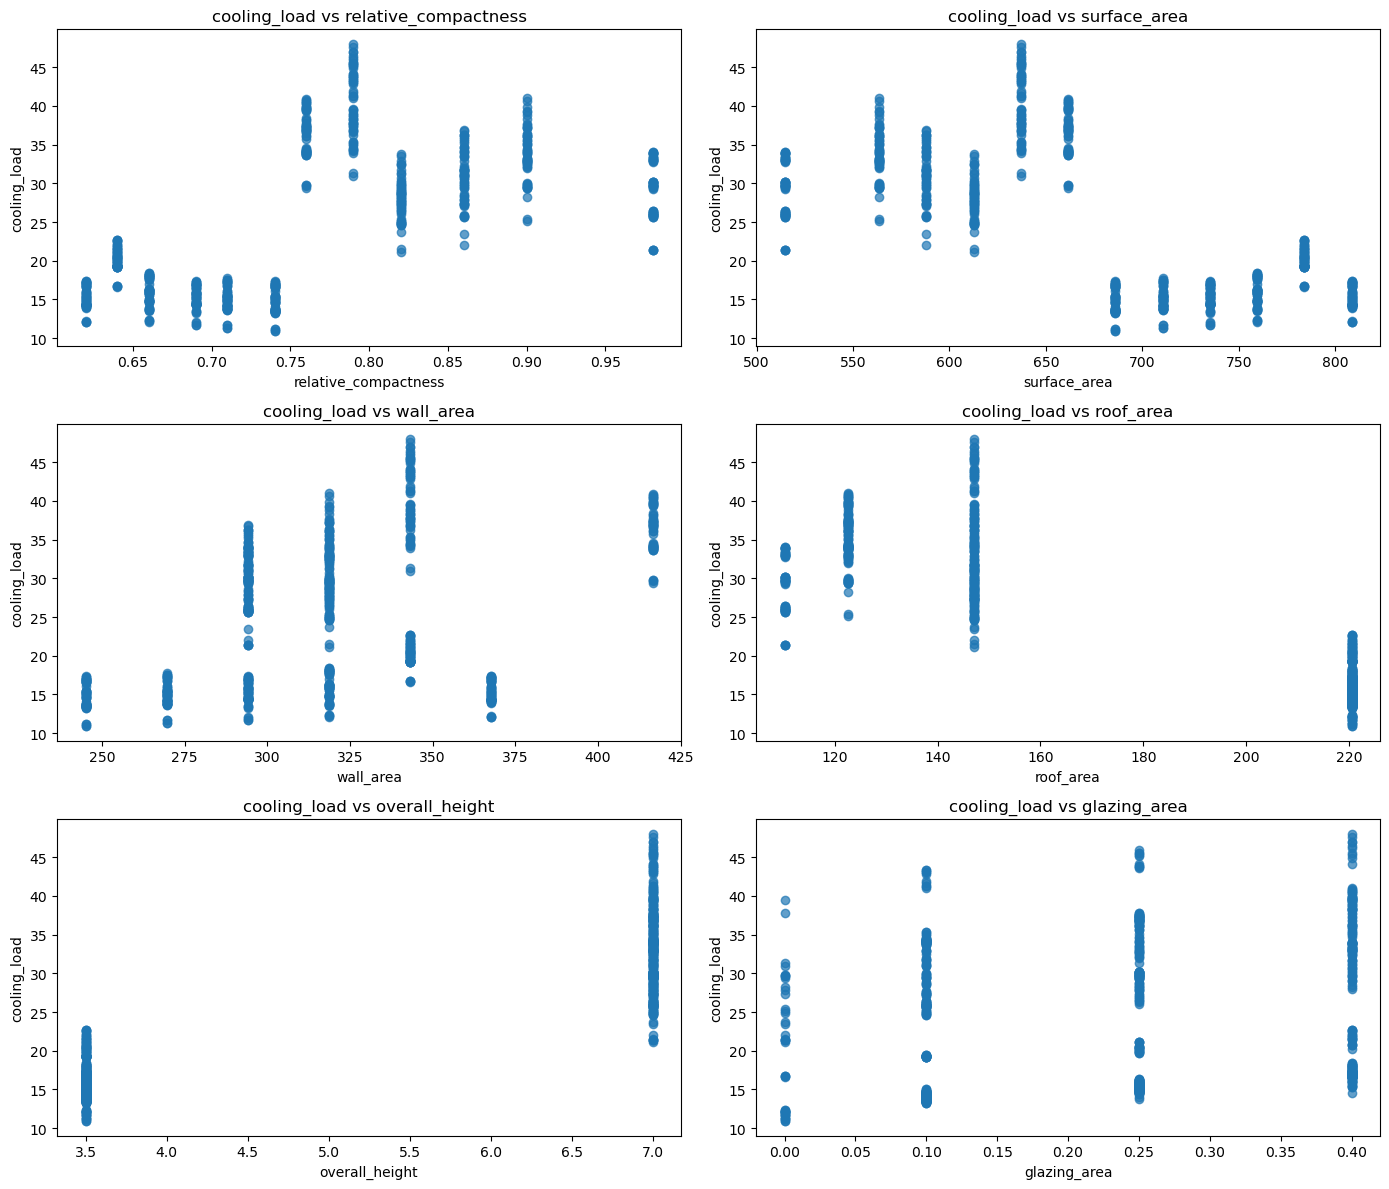

In [20]:
# ============================================================
# SCATTERPLOTS: CONTINUOUS FEATURES VS TARGETS
# ============================================================

for target in target_cols:
    n_cols = 2
    n_rows = int(np.ceil(len(continuous_features) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(continuous_features):
        axes[i].scatter(df[col], df[target], alpha=0.7)
        axes[i].set_title(f"{target} vs {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel(target)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


Grouped summary by orientation


heating_load                                        cooling_load                                       
                   count    mean  median     std    min     max        count    mean  median    std     min     max
orientation                                                                                                        
2                    192 22.3129 19.1300 10.1090 6.0700 42.7700          192 24.6045 22.2200 9.6094 10.9000 46.4400
3                    192 22.3807 19.0050 10.1405 6.0500 43.1000          192 24.3126 21.7550 9.3103 11.1900 47.5900
4                    192 22.2599 18.9500 10.1194 6.0100 42.7400          192 24.4803 22.1700 9.3752 10.9400 47.0100
5                    192 22.2754 18.6500 10.0706 6.0400 42.9600          192 24.9536 22.5100 9.8129 11.1700 48.0300

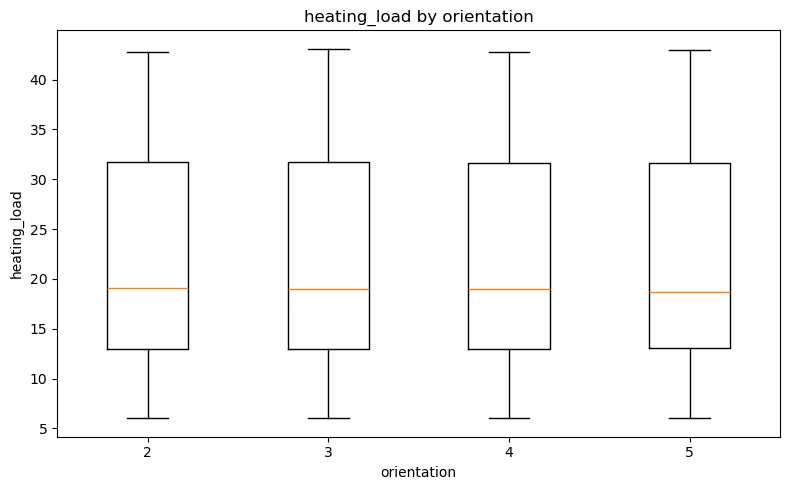

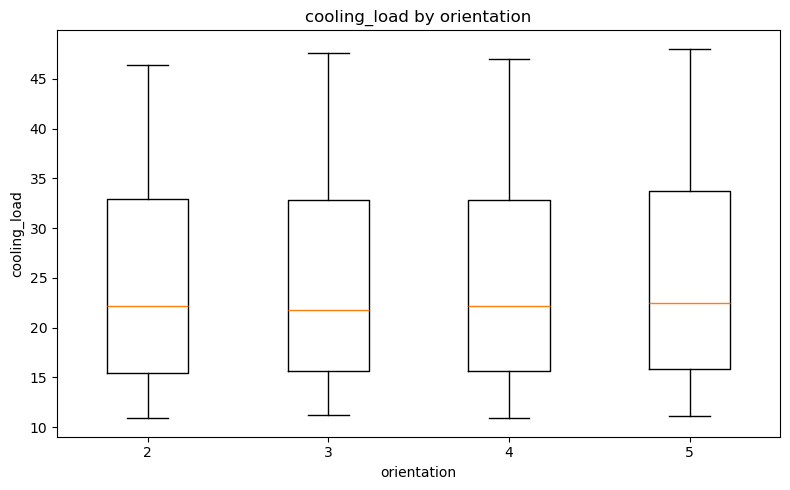


Grouped summary by glazing_area_distribution


heating_load                                         cooling_load                         \
                                 count    mean  median     std     min     max        count    mean  median    std   
glazing_area_distribution                                                                                            
0                                   48 14.2864 13.2000  7.6253  6.0100 29.9000           48 19.7063 18.9800 8.1344   
1                                  144 23.0261 21.0500 10.0319 10.3600 42.6200          144 25.1795 23.6700 9.5535   
2                                  144 22.9344 20.9950 10.0533 10.3200 43.1000          144 24.9969 23.4450 9.5593   
3                                  144 22.6815 20.8200  9.9905 10.3400 42.4900          144 24.6594 23.2350 9.4889   
4                                  144 22.8867 20.9650 10.0641 10.0700 42.9600          144 25.0151 23.5500 9.5625   
5                                  144 22.6809 20.5400 10.0518 10.3400 42.1100          144 24.7150 23.0850 9.5301   

                                           
                              min     max  
glazing_area_distribution                  
0                         10.9000 39.4400  
1                         13.4300 46.9400  
2                         13.2000 48.0300  
3                         13.3600 46.4400  
4                         13.2000 47.5900  
5                         13.4400 47.0100

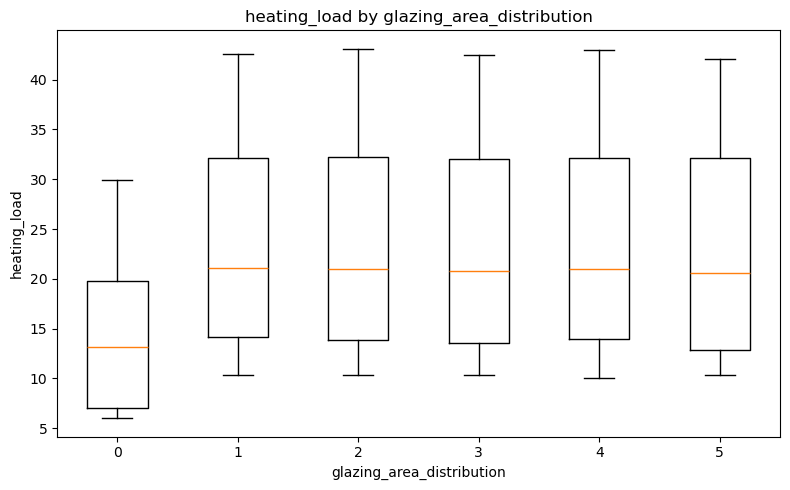

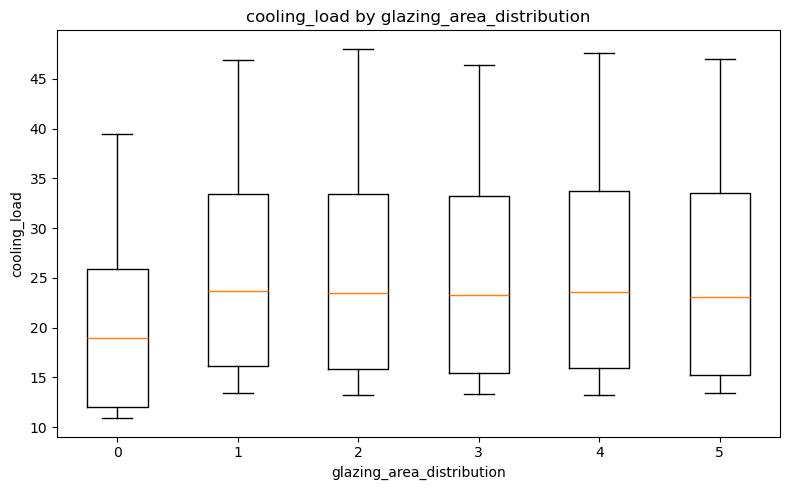

In [21]:
# ============================================================
# GROUPED TARGET SUMMARIES FOR CATEGORICAL FEATURES
# ============================================================

for cat in categorical_features:
    print(f"\nGrouped summary by {cat}")
    group_summary = df.groupby(cat, observed=False)[target_cols].agg(["count", "mean", "median", "std", "min", "max"])
    display(group_summary)

    for target in target_cols:
        plt.figure(figsize=(8, 5))
        data = [df.loc[df[cat] == level, target] for level in df[cat].cat.categories]
        labels = [str(level) for level in df[cat].cat.categories]
        plt.boxplot(data, labels=labels)
        plt.title(f"{target} by {cat}")
        plt.xlabel(cat)
        plt.ylabel(target)
        plt.tight_layout()
        plt.show()

In [22]:
# ============================================================
# ONE-WAY ANOVA FOR CATEGORICAL EFFECTS
# ============================================================

anova_results = []

for cat in categorical_features:
    for target in target_cols:
        groups = [group[target].values for _, group in df.groupby(cat, observed=False)]
        f_stat, p_value = stats.f_oneway(*groups)
        anova_results.append({
            "categorical_feature": cat,
            "target": target,
            "F_statistic": f_stat,
            "p_value": p_value,
        })

anova_results = pd.DataFrame(anova_results)
display(anova_results)

,categorical_feature,target,F_statistic,p_value
0,orientation,heating_load,0.0054,0.9994
1,orientation,cooling_load,0.1561,0.9258
2,glazing_area_distribution,heating_load,6.7409,0.0000
3,glazing_area_distribution,cooling_load,2.7894,0.0166


## Interaction-Oriented EDA

Energy performance is often interaction-driven. For example, the effect of glazing area may depend on building compactness, height, orientation, or wall/roof geometry. The following plots explore these relationships before formal modeling.


Mean heating_load by glazing_area and overall_height


overall_height,3.5000,7.0000
glazing_area,,
0.0000,7.5903,20.9825
0.1000,11.9984,28.7159
0.2500,13.5827,31.9312
0.4000,15.5841,35.2392


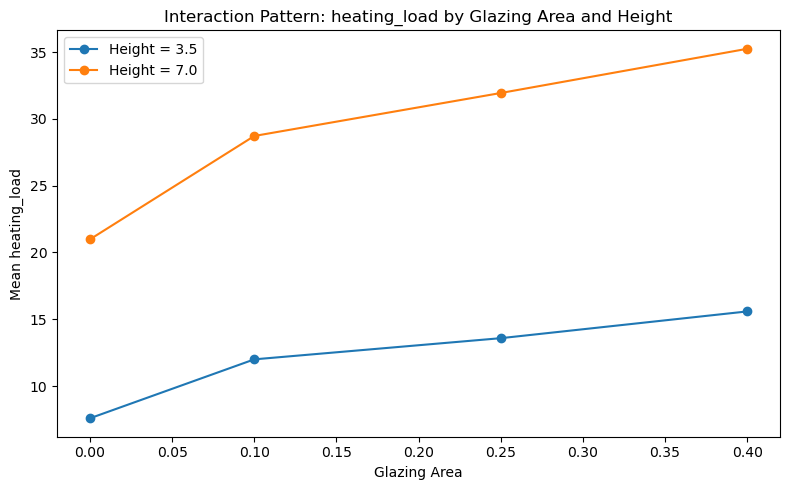


Mean cooling_load by glazing_area and overall_height


overall_height,3.5000,7.0000
glazing_area,,
0.0000,12.5908,26.8217
0.1000,14.9450,30.9261
0.2500,16.1853,33.5999
0.4000,17.7801,36.0427


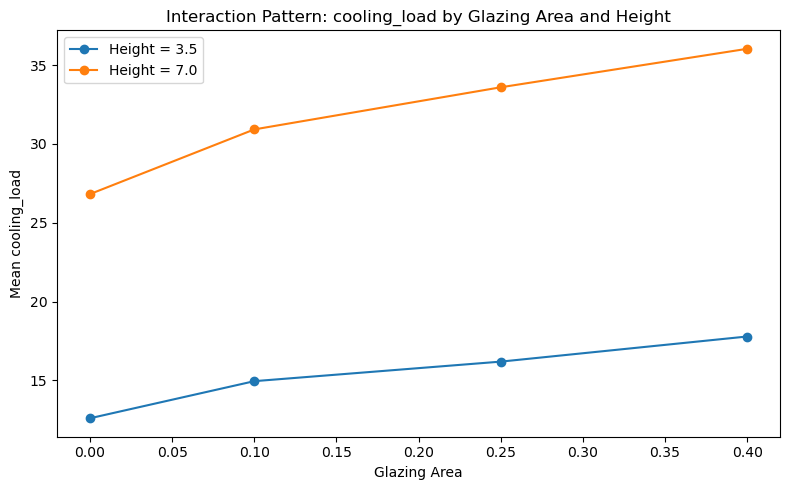

In [23]:
# ============================================================
# TARGET MEANS BY GLAZING AREA AND HEIGHT
# ============================================================

for target in target_cols:
    pivot = df.pivot_table(
        values=target,
        index="glazing_area",
        columns="overall_height",
        aggfunc="mean"
    )
    print(f"\nMean {target} by glazing_area and overall_height")
    display(pivot)

    plt.figure(figsize=(8, 5))
    for height in pivot.columns:
        plt.plot(pivot.index, pivot[height], marker="o", label=f"Height = {height}")
    plt.title(f"Interaction Pattern: {target} by Glazing Area and Height")
    plt.xlabel("Glazing Area")
    plt.ylabel(f"Mean {target}")
    plt.legend()
    plt.tight_layout()
    plt.show()


Mean heating_load by orientation and glazing_area_distribution


glazing_area_distribution,0,1,2,3,4,5
orientation,,,,,,
2,14.3458,22.9431,22.9458,22.4875,23.0264,22.8172
3,14.4642,23.2167,23.1478,22.7694,22.6869,22.7214
4,14.3680,23.1389,22.9136,22.7422,22.7297,22.4056
5,13.9675,22.8058,22.7306,22.7267,23.1036,22.7794


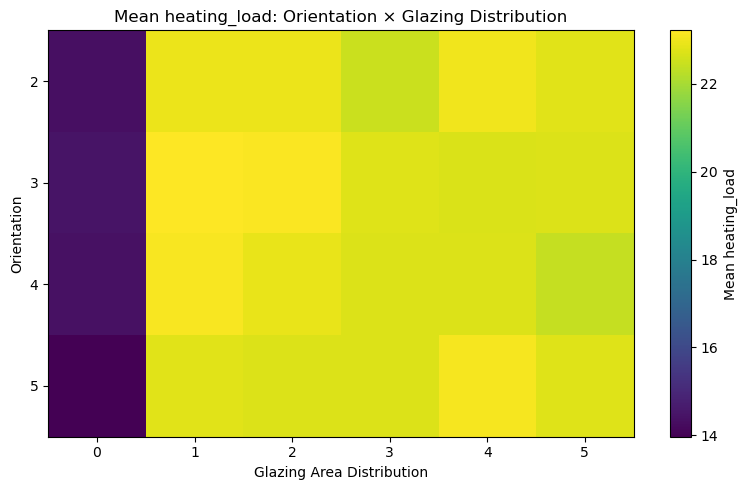


Mean cooling_load by orientation and glazing_area_distribution


glazing_area_distribution,0,1,2,3,4,5
orientation,,,,,,
2,20.2800,25.7186,25.3789,25.4311,24.0053,23.9303
3,18.9417,24.4639,24.1728,24.9753,25.9014,23.8397
4,18.9208,24.3331,24.2897,24.1522,25.7292,25.7506
5,20.6825,26.2025,26.1461,24.0792,24.4247,25.3394


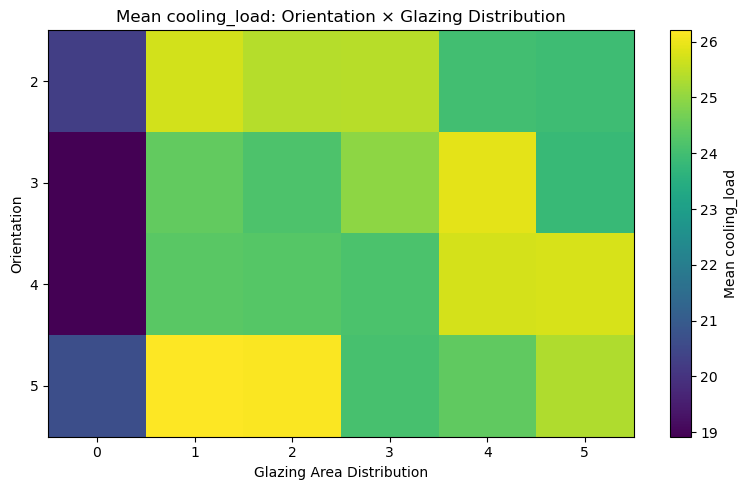

In [24]:
# ============================================================
# TARGET MEANS BY ORIENTATION AND GLAZING DISTRIBUTION
# ============================================================

for target in target_cols:
    pivot = df.pivot_table(
        values=target,
        index="orientation",
        columns="glazing_area_distribution",
        aggfunc="mean"
    )
    print(f"\nMean {target} by orientation and glazing_area_distribution")
    display(pivot)

    plt.figure(figsize=(8, 5))
    plt.imshow(pivot, aspect="auto")
    plt.colorbar(label=f"Mean {target}")
    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.title(f"Mean {target}: Orientation × Glazing Distribution")
    plt.xlabel("Glazing Area Distribution")
    plt.ylabel("Orientation")
    plt.tight_layout()
    plt.show()

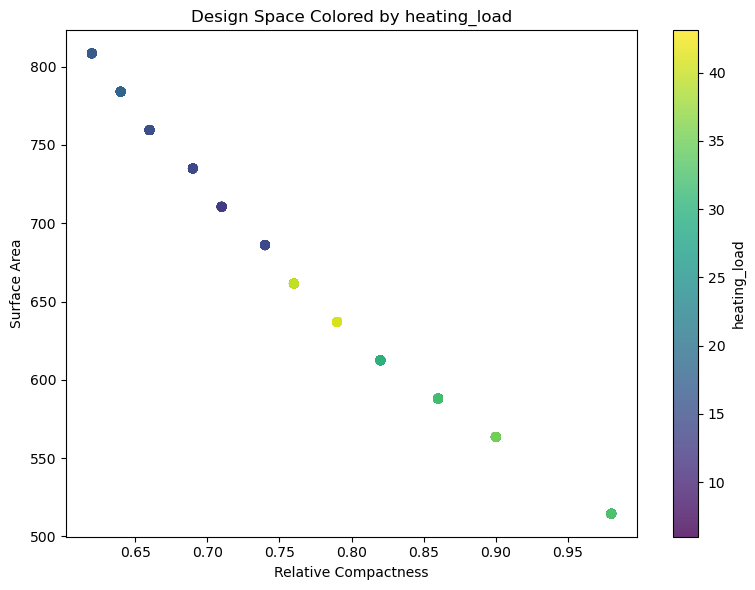

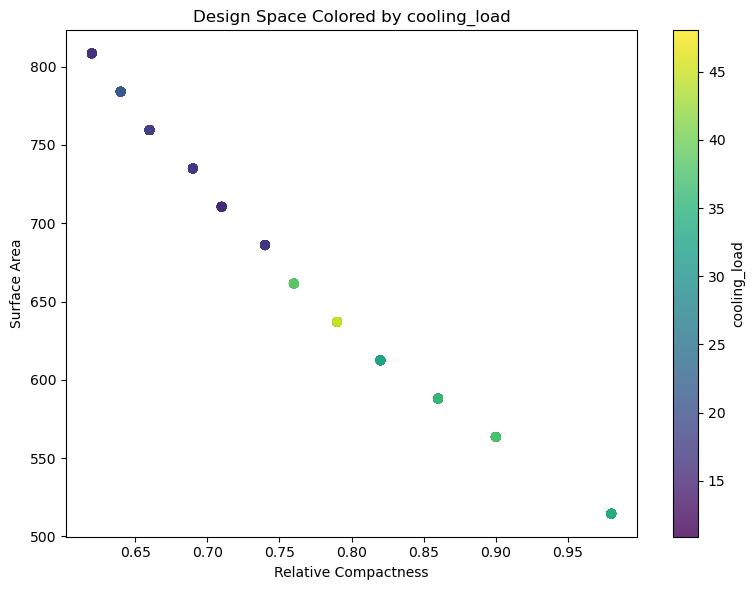

In [25]:
# ============================================================
# BIVARIATE DESIGN SPACE: COMPACTNESS, SURFACE AREA, TARGETS
# ============================================================

for target in target_cols:
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        df["relative_compactness"],
        df["surface_area"],
        c=df[target],
        alpha=0.8
    )
    plt.colorbar(scatter, label=target)
    plt.title(f"Design Space Colored by {target}")
    plt.xlabel("Relative Compactness")
    plt.ylabel("Surface Area")
    plt.tight_layout()
    plt.show()

## Non-Linearity and Feature Relevance Screening

Correlation captures only linear association. Mutual information is added because it can detect non-linear dependency between predictors and targets. This is helpful when comparing linear models with tree-based or spline-based models later.

,feature,target,mutual_information
9,surface_area,cooling_load,1.4210
8,relative_compactness,cooling_load,1.4175
11,roof_area,cooling_load,0.8799
10,wall_area,cooling_load,0.8683
14,glazing_area,cooling_load,0.7316
12,overall_height,cooling_load,0.6819
15,glazing_area_distribution,cooling_load,0.1469
13,orientation,cooling_load,0.0000
1,surface_area,heating_load,1.7299
0,relative_compactness,heating_load,1.7280


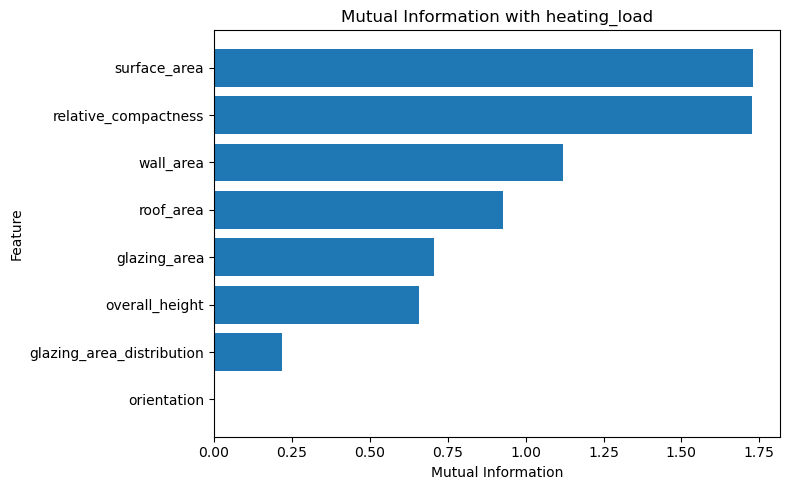

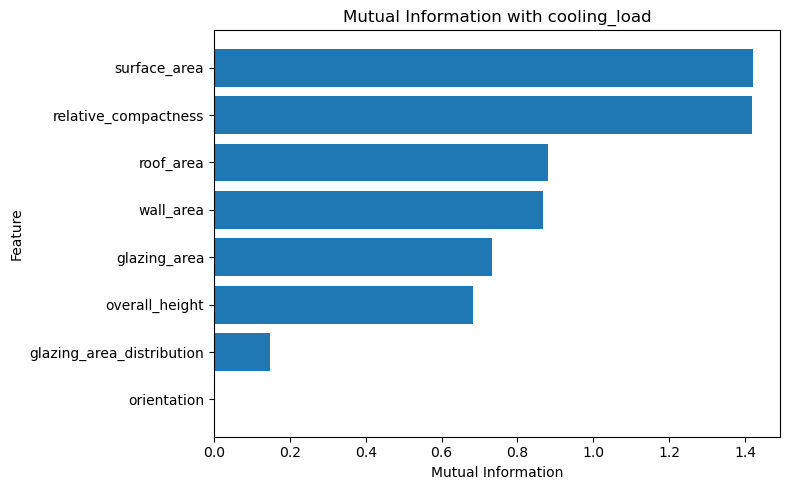

In [26]:
# ============================================================
# MUTUAL INFORMATION WITH TARGETS
# ============================================================

X_mi = numeric_df[feature_cols].astype(float)

mi_tables = []
for target in target_cols:
    mi = mutual_info_regression(X_mi, df[target], random_state=42)
    temp = pd.DataFrame({
        "feature": feature_cols,
        "target": target,
        "mutual_information": mi,
    })
    mi_tables.append(temp)

mi_table = pd.concat(mi_tables, ignore_index=True)
mi_table = mi_table.sort_values(["target", "mutual_information"], ascending=[True, False])
display(mi_table)

for target in target_cols:
    temp = mi_table[mi_table["target"] == target].sort_values("mutual_information")
    plt.figure(figsize=(8, 5))
    plt.barh(temp["feature"], temp["mutual_information"])
    plt.title(f"Mutual Information with {target}")
    plt.xlabel("Mutual Information")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

## Dimensionality and Design Pattern Exploration

PCA is used as an exploratory tool to understand whether the building design features occupy a lower-dimensional design space because of geometric constraints and experimental design structure.

,principal_component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.4629,0.4629
1,PC2,0.1550,0.6178
2,PC3,0.1516,0.7695
3,PC4,0.1250,0.8945
4,PC5,0.0984,0.9928
5,PC6,0.0066,0.9994
6,PC7,0.0006,1.0000
7,PC8,0.0000,1.0000


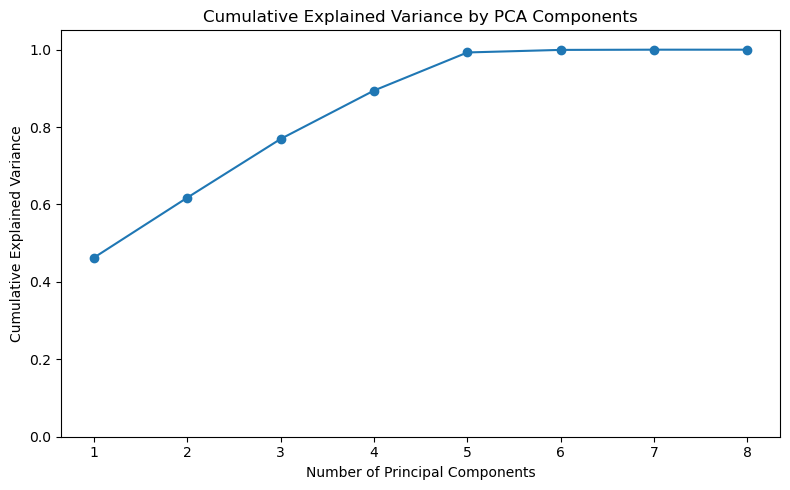

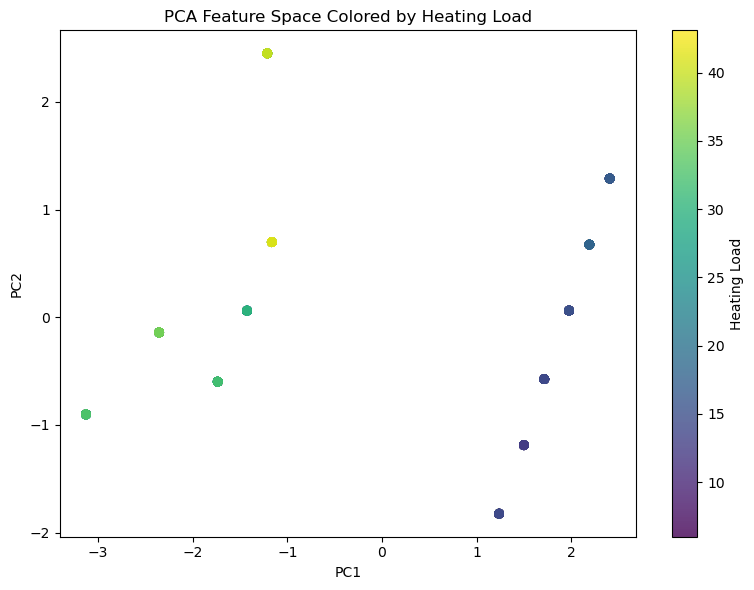

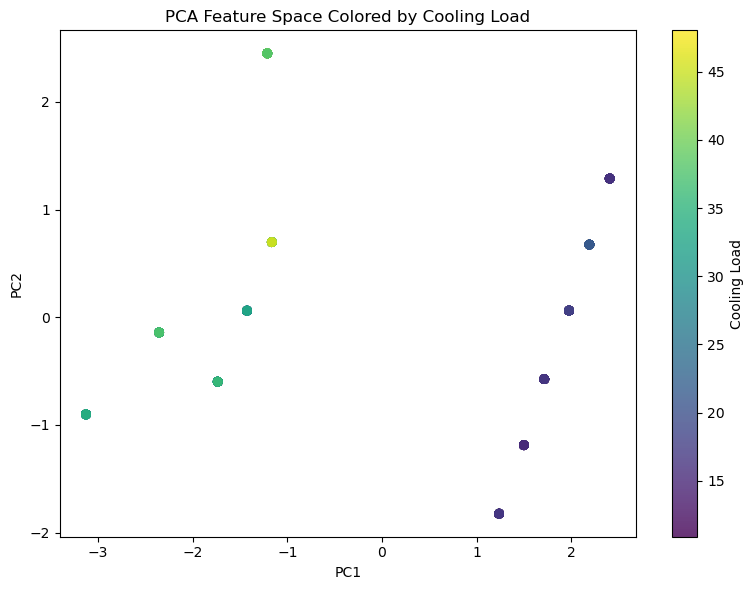

In [27]:
# ============================================================
# PCA OF FEATURE SPACE
# ============================================================

X_scaled = StandardScaler().fit_transform(X_mi)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

pca_summary = pd.DataFrame({
    "principal_component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_),
})

display(pca_summary)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["heating_load"], alpha=0.8)
plt.colorbar(scatter, label="Heating Load")
plt.title("PCA Feature Space Colored by Heating Load")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["cooling_load"], alpha=0.8)
plt.colorbar(scatter, label="Cooling Load")
plt.title("PCA Feature Space Colored by Cooling Load")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

In [28]:
# ============================================================
# PCA LOADINGS
# ============================================================

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=[f"PC{i+1}" for i in range(len(feature_cols))]
)

display(loadings)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
relative_compactness,-0.4960,-0.2447,0.0000,0.0000,0.0000,-0.4952,0.6700,-0.0000
surface_area,0.5017,0.2315,-0.0000,-0.0000,-0.0000,0.0662,0.5049,-0.6598
wall_area,-0.0325,0.8943,-0.0000,0.0000,0.0000,-0.2911,0.0874,0.3268
roof_area,0.5050,-0.2061,0.0000,0.0000,0.0000,0.2052,0.4501,0.6766
overall_height,-0.4962,0.2104,-0.0000,0.0000,-0.0000,0.7897,0.2931,-0.0000
orientation,0.0000,0.0000,0.0000,1.0000,-0.0000,-0.0000,-0.0000,-0.0000
glazing_area,0.0000,0.0000,0.7071,-0.0000,-0.7071,-0.0000,0.0000,0.0000
glazing_area_distribution,0.0000,0.0000,0.7071,-0.0000,0.7071,-0.0000,0.0000,-0.0000


# EDA Summary and Modeling Implications

The exploratory analysis revealed several important characteristics of the building energy efficiency dataset that directly influence model selection.

### Key Findings

1. **The dataset is complete and of high quality.**
   - No missing values were observed.
   - No substantial outlier issues were detected.
   - The dataset is suitable for predictive modeling without extensive preprocessing.

2. **Heating Load and Cooling Load are strongly related.**
   - Pearson correlation between the targets is approximately 0.98.
   - Buildings that require higher heating loads generally require higher cooling loads.
   - This suggests that both targets are driven by similar underlying design characteristics.

3. **Building geometry is the dominant driver of energy demand.**
   - Overall Height exhibits the strongest correlation with both Heating Load and Cooling Load.
   - Roof Area, Relative Compactness, Surface Area, and Wall Area also show substantial associations with the targets.
   - Glazing Area has a moderate effect, while Orientation appears to have little influence.

4. **Orientation contributes very little predictive information.**
   - ANOVA results show no statistically significant differences in Heating Load or Cooling Load across orientation categories.
   - Orientation is therefore expected to be a weak predictor in most models.

5. **Glazing Area Distribution has a statistically significant effect.**
   - ANOVA results indicate meaningful differences in both Heating Load and Cooling Load across glazing distribution patterns.
   - This variable should be retained for modeling.

6. **Severe multicollinearity exists among geometric variables.**
   - Relative Compactness and Surface Area are almost perfectly correlated.
   - Roof Area and Overall Height are also strongly correlated.
   - VIF analysis reveals extremely large and even infinite VIF values for several predictors.
   - Coefficient interpretation from ordinary linear regression should therefore be approached cautiously.

7. **Evidence of interaction effects is present.**
   - Heating and Cooling Loads increase systematically with combinations of higher glazing area and greater building height.
   - Energy demand appears to depend on combinations of design characteristics rather than individual variables alone.

8. **Non-linear relationships are likely present.**
   - Mutual Information analysis shows substantial predictor relevance beyond what is captured by simple linear correlation.
   - Several predictor-target relationships appear curved rather than strictly linear in the scatterplots.

9. **The predictor space is highly structured.**
   - PCA indicates that a small number of latent dimensions explain most of the variation in the building designs.
   - This further supports the presence of strong geometric dependencies among predictors.

---

## Modeling Implications

Based on the EDA findings, the following modeling strategy is recommended.

### Parametric Models

1. **Multiple Linear Regression**
   - Serves as the baseline model.
   - Provides interpretability and statistical inference.
   - Expected to perform reasonably well but may be affected by multicollinearity and non-linear relationships.

2. **Regularized Regression**
   - Ridge Regression
   - LASSO Regression
   - Elastic Net Regression

   These models are strongly recommended because they mitigate the severe multicollinearity identified during EDA.

### Semi-Parametric Models

3. **Generalized Additive Models (GAMs)**
   - Appropriate because several predictors exhibit non-linear effects.
   - Retain interpretability while allowing flexible functional relationships.

### Non-Linear Machine Learning Models

4. **Random Forest Regression**
   - Naturally captures interactions and non-linear relationships.
   - Robust to multicollinearity.
   - Provides feature importance measures.

5. **Gradient Boosting Models**
   - XGBoost
   - LightGBM
   - CatBoost

   Expected to achieve strong predictive performance due to their ability to model complex predictor-target relationships.

6. **Support Vector Regression (SVR)**
   - Particularly useful if the predictor-target relationship is highly non-linear.
   - Suitable for benchmarking against tree-based methods.

7. **Artificial Neural Networks**
   - Can capture complex interactions and non-linearities.
   - Should be considered as an advanced modeling approach rather than a baseline model due to the relatively small dataset size.

---

## Recommended Modeling Pipeline

The recommended progression for this study is:

1. Multiple Linear Regression (baseline)
2. Ridge Regression
3. LASSO Regression
4. Generalized Additive Model (GAM)
5. Random Forest Regression
6. Gradient Boosting (XGBoost / LightGBM)
7. Support Vector Regression
8. Neural Network Regression

This sequence allows comparison between parametric, semi-parametric, and non-linear modeling paradigms while remaining consistent with the patterns observed during exploratory data analysis.